# 🎬 KalaburagiTech Netflix Analytics Platform (EDA)

Enterprise Exploratory Data Analysis on the Netflix Movies & TV Shows Dataset.
Engineered and maintained by **KalaburagiTech**.

This notebook performs end-to-end data ingestion, reproducible cleaning, and analytical visualizations exploring content types, maturity ratings, movie durations, international production hubs, genre distributions, and historical release trends.


## 1. Setup & Data Ingestion

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Ensure outputs directory exists
output_dir = Path('outputs')
if not output_dir.exists() and (Path('..') / 'outputs').exists():
    output_dir = Path('..') / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)

# Locate dataset with relative fallback
candidates = [
    Path('data') / 'netflix_titles.csv',
    Path('..') / 'data' / 'netflix_titles.csv',
    Path('netflix_titles.csv'),
    Path('..') / 'netflix_titles.csv'
]

data_path = None
for c in candidates:
    if c.exists():
        data_path = c
        break

if not data_path:
    raise FileNotFoundError(f'Could not find netflix_titles.csv in {candidates}')

df = pd.read_csv(data_path)
print(f'Loaded raw dataset from {data_path}: {df.shape[0]} rows, {df.shape[1]} columns')
df.head(3)


Loaded raw dataset from ..\data\netflix_titles.csv: 8807 rows, 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


## 2. Data Cleaning

Drop records where critical fields (`type`, `release_year`, `rating`, `country`, `duration`) are missing.

In [2]:
clean_subset = ['type', 'release_year', 'rating', 'country', 'duration']
df_clean = df.dropna(subset=clean_subset).copy()
print(f'Cleaned dataset shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns')

Cleaned dataset shape: 7970 rows, 12 columns


## 3. Number of Movies vs TV Shows

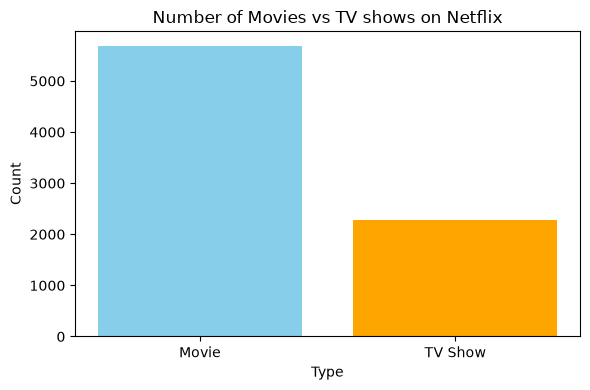

In [3]:
type_count = df_clean['type'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(type_count.index, type_count.values, color=['skyblue', 'orange'])
plt.title('Number of Movies vs TV shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(output_dir / 'movies_vs_tv.png')
plt.savefig('movies_vs_tv.png')
plt.show()

## 4. Percentage of Content Ratings

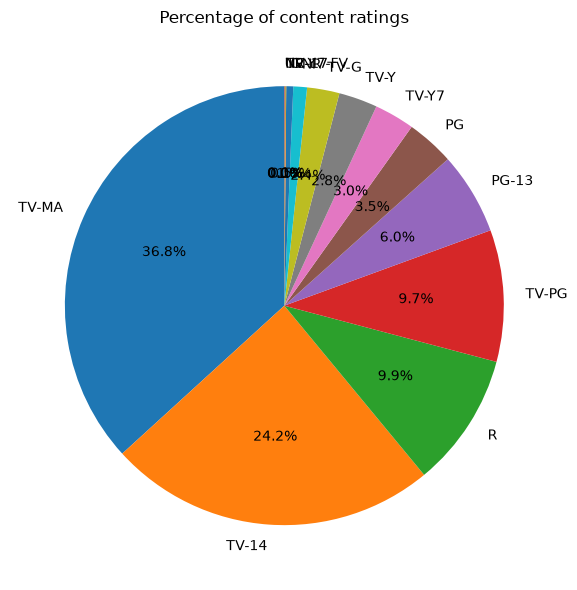

In [4]:
rating_count = df_clean['rating'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(rating_count, labels=rating_count.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of content ratings')
plt.tight_layout()
plt.savefig(output_dir / 'content_rating_pie.png')
plt.savefig('content_rating_pie.png')
plt.show()

## 5. Distribution of Movie Duration

Note: Saved to `movie_dur_hist.png` (fixing original bug where it overwrote `movies_vs_tv.png`).

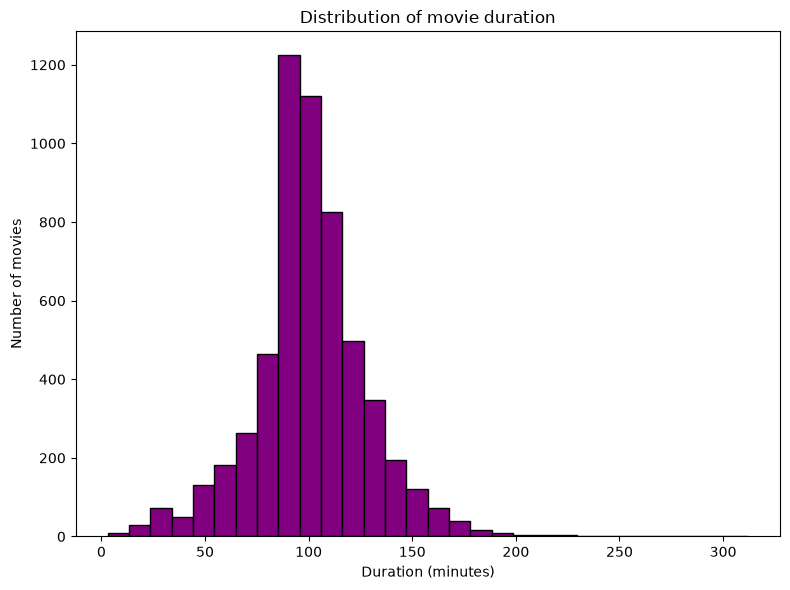

In [5]:
movies_df = df_clean[df_clean['type'] == 'Movie'].copy()
movies_df['duration_int'] = movies_df['duration'].str.replace('min', '', regex=False).str.strip().astype(int)

plt.figure(figsize=(8, 6))
plt.hist(movies_df['duration_int'], bins=30, color='purple', edgecolor='black')
plt.title('Distribution of movie duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of movies')
plt.tight_layout()
plt.savefig(output_dir / 'movie_dur_hist.png')
plt.savefig('movie_dur_hist.png')
plt.show()

## 6. Top 10 Countries Producing Content

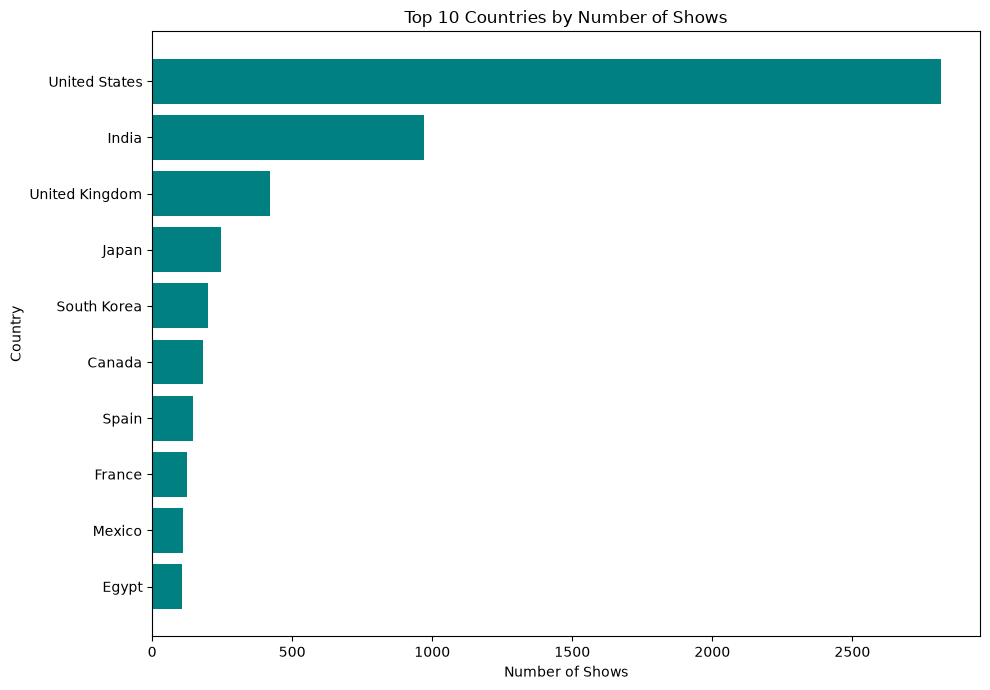

In [6]:
top10 = df_clean['country'].value_counts().head(10)

plt.figure(figsize=(10, 7))
plt.barh(top10.index[::-1], top10.values[::-1], color='teal')
plt.title('Top 10 Countries by Number of Shows')
plt.xlabel('Number of Shows')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig(output_dir / 'top10_countries.png')
plt.savefig('top10_countries.png')
plt.show()

## 7. Release Year vs Number of Shows

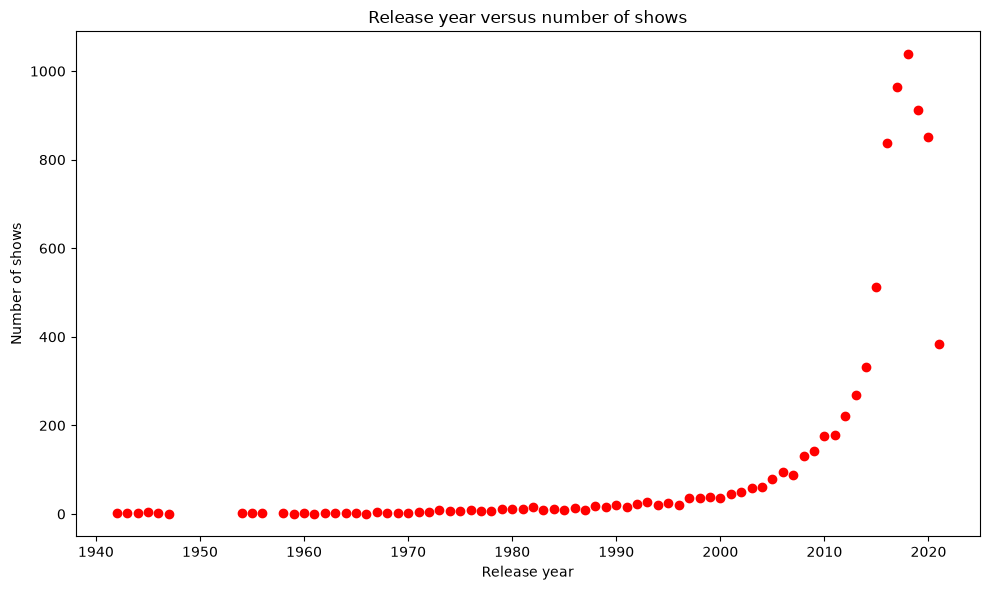

In [7]:
release_counts = df_clean['release_year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.scatter(release_counts.index, release_counts.values, color='red')
plt.title('Release year versus number of shows')
plt.xlabel('Release year')
plt.ylabel('Number of shows')
plt.tight_layout()
plt.savefig(output_dir / 'release_year_vs_show.png')
plt.savefig('release_year_vs_show.png')
plt.show()

## 8. Comparison of Movies and TV Shows Released Over Years

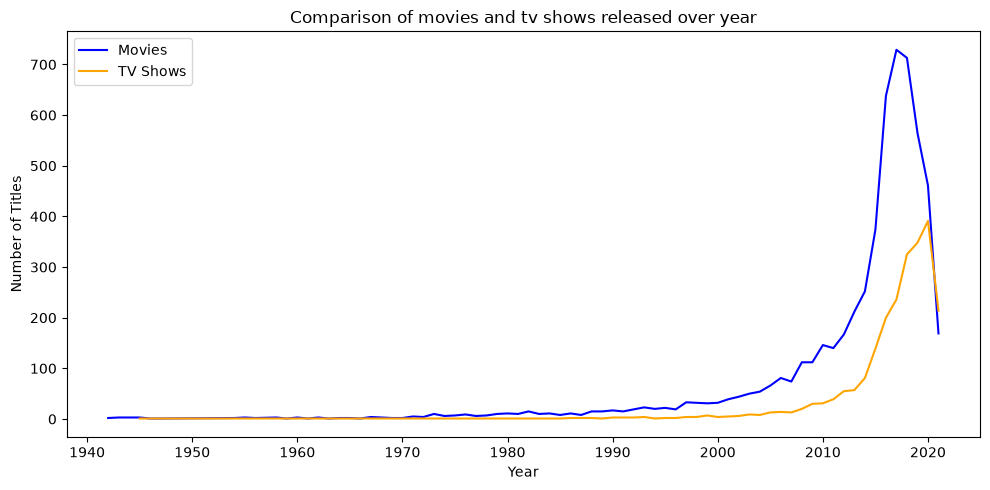

In [8]:
movies_by_year = df_clean[df_clean['type'] == 'Movie']['release_year'].value_counts().sort_index()
tv_by_year = df_clean[df_clean['type'] == 'TV Show']['release_year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(movies_by_year.index, movies_by_year.values, color='blue', label='Movies')
plt.plot(tv_by_year.index, tv_by_year.values, color='orange', label='TV Shows')
plt.title('Comparison of movies and tv shows released over year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / 'movies_tv_shows_comp.png')
plt.savefig('movies_tv_shows_comp.png')
plt.show()

## 9. Top Genres in Movies vs TV Shows

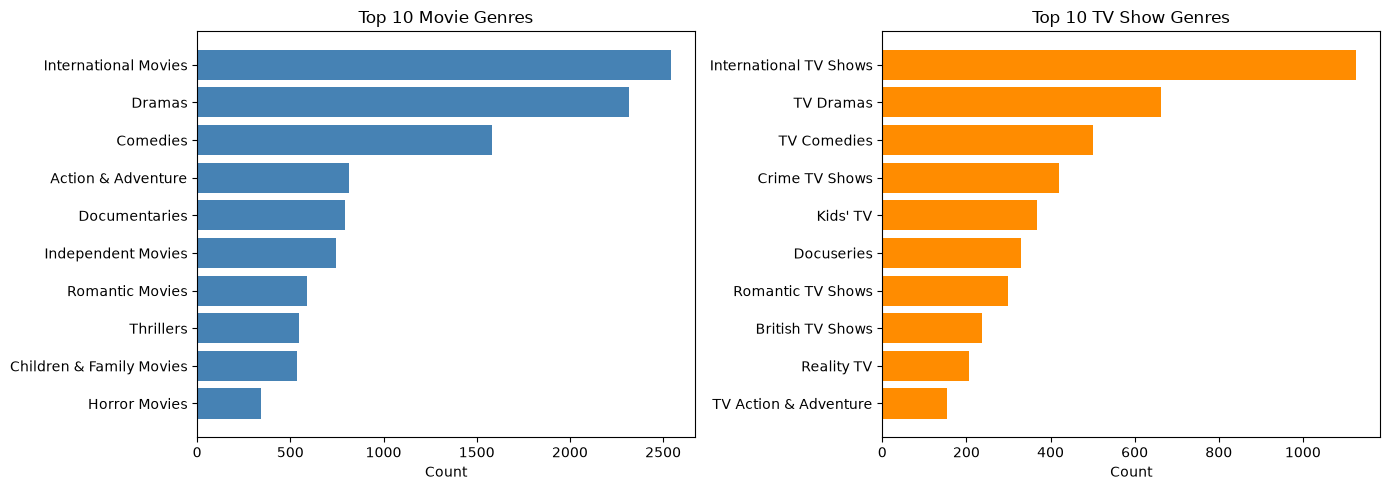

In [9]:
movie_genres = df_clean[df_clean['type'] == 'Movie']['listed_in'].str.split(', ').explode().value_counts().head(10)
tv_genres = df_clean[df_clean['type'] == 'TV Show']['listed_in'].str.split(', ').explode().value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(movie_genres.index[::-1], movie_genres.values[::-1], color='steelblue')
axes[0].set_title('Top 10 Movie Genres')
axes[0].set_xlabel('Count')

axes[1].barh(tv_genres.index[::-1], tv_genres.values[::-1], color='darkorange')
axes[1].set_title('Top 10 TV Show Genres')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig(output_dir / 'genre_distribution.png')
plt.show()